In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize']=8,3
sns.set_theme(style="whitegrid", palette="dark")

In [2]:
profession=pd.read_csv(r'C:\Users\admin\Downloads\archive\age_interest_career_dataset.csv')

In [3]:
profession

,gender,age,age_group,attention_span,creativity_score,logical_reasoning,verbal_intelligence,visual_intelligence,social_skills,motor_skills,...,Math Interest,Computer Games,Social Media Usage,Technology Interest,Career Goals,University Choices,Future Planning,primary_interest,secondary_interest,predicted_job
0,Male,11,9-12,4,4,6,4,7,3,5,...,7.0,NaN,NaN,NaN,NaN,NaN,NaN,Science,Drawing,Graphic Designer
1,Female,8,5-8,7,1,7,10,10,5,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Animals,Drawing,Animal Caretaker
2,Male,17,16-18,3,2,10,10,5,9,3,...,NaN,NaN,NaN,NaN,9.0,9.0,1.0,Artificial Intelligence,Psychology,AI Engineer
3,Female,15,13-15,6,1,7,3,3,2,9,...,NaN,2.0,7.0,3.0,NaN,NaN,NaN,Coding,Sports,Software Developer
4,Female,12,9-12,2,5,10,10,7,10,7,...,6.0,NaN,NaN,NaN,NaN,NaN,NaN,Nature,Dance,Choreographer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Male,18,16-18,10,10,10,9,5,4,10,...,NaN,NaN,NaN,NaN,2.0,10.0,4.0,Theatre,Artificial Intelligence,Stage Director
96,Male,8,5-8,3,1,6,7,4,8,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Animals,Games,Child Educator
97,Male,18,16-18,7,8,5,5,3,5,8,...,NaN,NaN,NaN,NaN,10.0,7.0,2.0,Artificial Intelligence,Psychology,Psychologist
98,Male,12,9-12,10,1,4,10,6,2,6,...,8.0,NaN,NaN,NaN,NaN,NaN,NaN,Nature,Dance,Environmental Engineer


In [4]:
profession.shape

(100, 25)

In [5]:
profession.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   gender                         100 non-null    object 
 1   age                            100 non-null    int64  
 2   age_group                      100 non-null    object 
 3   attention_span                 100 non-null    int64  
 4   creativity_score               100 non-null    int64  
 5   logical_reasoning              100 non-null    int64  
 6   verbal_intelligence            100 non-null    int64  
 7   visual_intelligence            100 non-null    int64  
 8   social_skills                  100 non-null    int64  
 9   motor_skills                   100 non-null    int64  
 10  Fairy Tale Interest            27 non-null     float64
 11  Motor Skills (Group Specific)  27 non-null     float64
 12  Color Cards                    27 non-null     floa

In [6]:
numeric_cols = profession.select_dtypes(include=['number']).columns
profession[numeric_cols] = profession[numeric_cols].fillna(profession[numeric_cols].mean())

categorical_cols = profession.select_dtypes(include=['object']).columns
for col in categorical_cols:
    profession[col] = profession[col].fillna(profession[col].mode()[0])


In [7]:
profession.isnull().sum()

gender                           0
age                              0
age_group                        0
attention_span                   0
creativity_score                 0
logical_reasoning                0
verbal_intelligence              0
visual_intelligence              0
social_skills                    0
motor_skills                     0
Fairy Tale Interest              0
Motor Skills (Group Specific)    0
Color Cards                      0
Reading Books                    0
Science Knowledge                0
Math Interest                    0
Computer Games                   0
Social Media Usage               0
Technology Interest              0
Career Goals                     0
University Choices               0
Future Planning                  0
primary_interest                 0
secondary_interest               0
predicted_job                    0
dtype: int64

In [8]:
profession.dtypes

gender                            object
age                                int64
age_group                         object
attention_span                     int64
creativity_score                   int64
logical_reasoning                  int64
verbal_intelligence                int64
visual_intelligence                int64
social_skills                      int64
motor_skills                       int64
Fairy Tale Interest              float64
Motor Skills (Group Specific)    float64
Color Cards                      float64
Reading Books                    float64
Science Knowledge                float64
Math Interest                    float64
Computer Games                   float64
Social Media Usage               float64
Technology Interest              float64
Career Goals                     float64
University Choices               float64
Future Planning                  float64
primary_interest                  object
secondary_interest                object
predicted_job   

In [9]:
profession.columns

Index(['gender', 'age', 'age_group', 'attention_span', 'creativity_score',
       'logical_reasoning', 'verbal_intelligence', 'visual_intelligence',
       'social_skills', 'motor_skills', 'Fairy Tale Interest',
       'Motor Skills (Group Specific)', 'Color Cards', 'Reading Books',
       'Science Knowledge', 'Math Interest', 'Computer Games',
       'Social Media Usage', 'Technology Interest', 'Career Goals',
       'University Choices', 'Future Planning', 'primary_interest',
       'secondary_interest', 'predicted_job'],
      dtype='object')

In [10]:
profession.columns=['gender', 'age', 'age_group', 'attention_span', 'creativity_score','logical_reasoning', 'verbal_intelligence', 'visual_intelligence','social_skills', 'motor_skills', 'Fairy_Tale_Interest','Motor_Skills', 'Color_Cards', 'Reading_Books','Science_Knowledge', 'Math_Interest', 'Computer_Games','Social_Media_Usage', 'Technology_Interest', 'Career_Goals','University_Choices', 'Future_Planning', 'primary_interest','secondary_interest', 'predicted_job']

In [11]:
len(profession.columns)

25

In [12]:
profession.describe()

,age,attention_span,creativity_score,logical_reasoning,verbal_intelligence,visual_intelligence,social_skills,motor_skills,Fairy_Tale_Interest,Motor_Skills,Color_Cards,Reading_Books,Science_Knowledge,Math_Interest,Computer_Games,Social_Media_Usage,Technology_Interest,Career_Goals,University_Choices,Future_Planning
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,11.880000,5.310000,4.740000,5.900000,5.410000,5.720000,4.830000,5.860000,5.518519,5.592593,4.296296,5.214286,6.392857,5.607143,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111
std,4.040902,2.973604,2.812742,2.879745,3.075137,2.909684,2.944109,2.971311,1.629094,1.233041,1.522988,1.274118,1.513170,1.416635,1.190356,1.063632,1.027129,1.495473,1.526423,1.628864
min,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,8.000000,3.000000,2.000000,4.000000,3.000000,3.000000,2.000000,3.000000,5.518519,5.592593,4.296296,5.214286,6.392857,5.607143,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111
50%,12.000000,5.500000,4.000000,6.000000,5.000000,6.000000,5.000000,6.000000,5.518519,5.592593,4.296296,5.214286,6.392857,5.607143,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111
75%,16.000000,8.000000,7.000000,8.000000,8.000000,8.000000,7.000000,9.000000,5.518519,5.592593,4.296296,5.214286,6.392857,5.607143,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111
max,18.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,9.000000,8.000000,10.000000,10.000000,10.000000


In [13]:
profession.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,100.0,11.880000,4.040902,5.0,8.000000,12.000000,16.000000,18.0
attention_span,100.0,5.310000,2.973604,1.0,3.000000,5.500000,8.000000,10.0
creativity_score,100.0,4.740000,2.812742,1.0,2.000000,4.000000,7.000000,10.0
logical_reasoning,100.0,5.900000,2.879745,1.0,4.000000,6.000000,8.000000,10.0
verbal_intelligence,100.0,5.410000,3.075137,1.0,3.000000,5.000000,8.000000,10.0
visual_intelligence,100.0,5.720000,2.909684,1.0,3.000000,6.000000,8.000000,10.0
social_skills,100.0,4.830000,2.944109,1.0,2.000000,5.000000,7.000000,10.0
motor_skills,100.0,5.860000,2.971311,1.0,3.000000,6.000000,9.000000,10.0
Fairy_Tale_Interest,100.0,5.518519,1.629094,1.0,5.518519,5.518519,5.518519,10.0
Motor_Skills,100.0,5.592593,1.233041,1.0,5.592593,5.592593,5.592593,10.0


In [14]:
profession.head()

,gender,age,age_group,attention_span,creativity_score,logical_reasoning,verbal_intelligence,visual_intelligence,social_skills,motor_skills,...,Math_Interest,Computer_Games,Social_Media_Usage,Technology_Interest,Career_Goals,University_Choices,Future_Planning,primary_interest,secondary_interest,predicted_job
0,Male,11,9-12,4,4,6,4,7,3,5,...,7.000000,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111,Science,Drawing,Graphic Designer
1,Female,8,5-8,7,1,7,10,10,5,2,...,5.607143,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111,Animals,Drawing,Animal Caretaker
2,Male,17,16-18,3,2,10,10,5,9,3,...,5.607143,5.611111,5.666667,4.555556,9.000000,9.000000,1.000000,Artificial Intelligence,Psychology,AI Engineer
3,Female,15,13-15,6,1,7,3,3,2,9,...,5.607143,2.000000,7.000000,3.000000,5.851852,5.888889,6.111111,Coding,Sports,Software Developer
4,Female,12,9-12,2,5,10,10,7,10,7,...,6.000000,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111,Nature,Dance,Choreographer


<Axes: xlabel='age', ylabel='Density'>

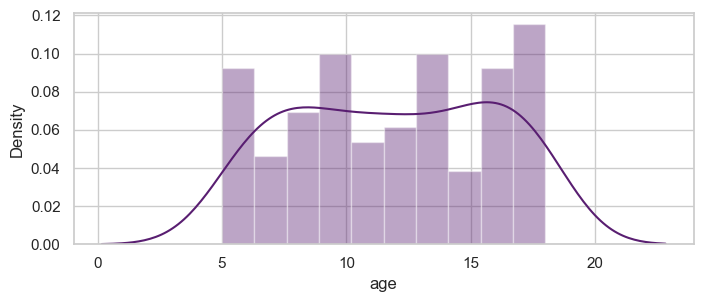

In [15]:
sns.distplot(profession.age,color='m',bins=10)

<Axes: xlabel='attention_span', ylabel='Density'>

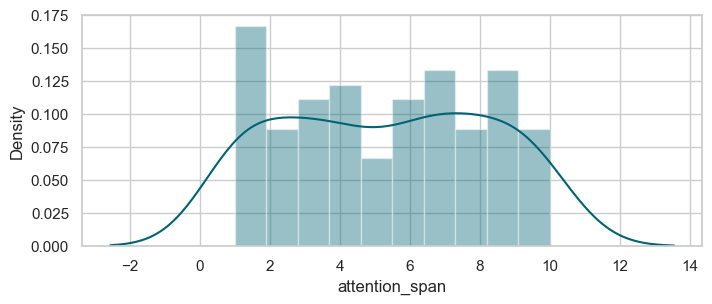

In [16]:
sns.distplot(profession.attention_span,color='c',bins=10)

<Axes: xlabel='creativity_score', ylabel='Density'>

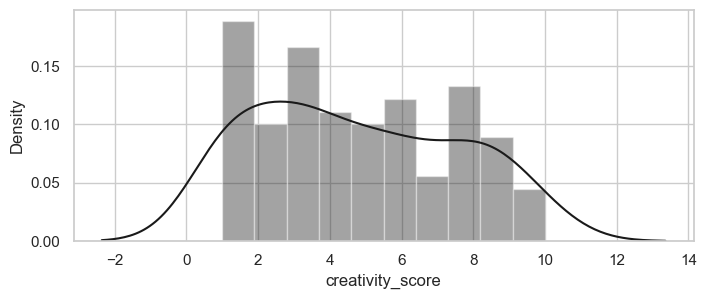

In [17]:
sns.distplot(profession.creativity_score,color='k',bins=10)

<Axes: xlabel='logical_reasoning', ylabel='Density'>

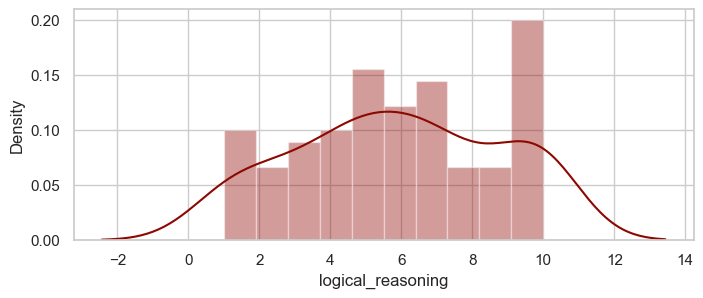

In [18]:
sns.distplot(profession.logical_reasoning,color='r',bins=10)

<Axes: xlabel='verbal_intelligence', ylabel='Density'>

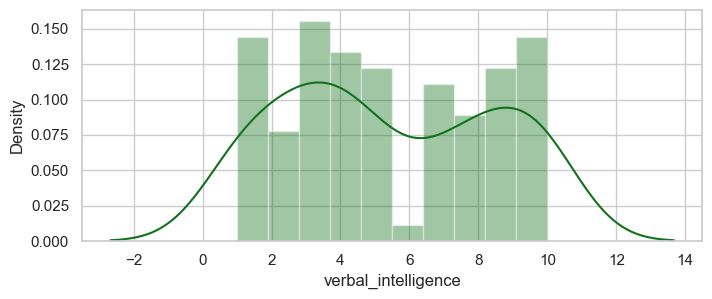

In [19]:
sns.distplot(profession.verbal_intelligence	,color='g',bins=10)

<Axes: xlabel='visual_intelligence', ylabel='Density'>

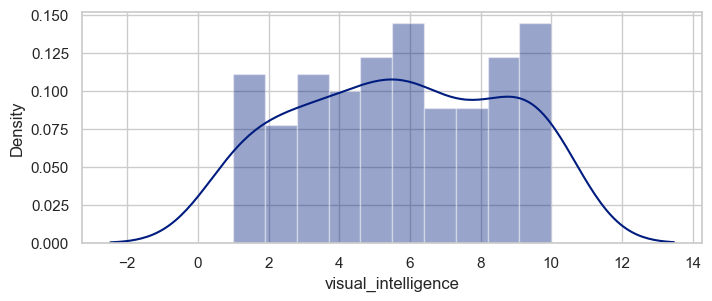

In [20]:
sns.distplot(profession.visual_intelligence,color='b',bins=10)

<Axes: xlabel='Future_Planning', ylabel='Density'>

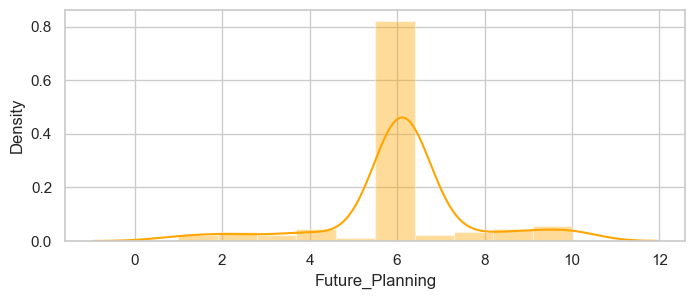

In [21]:
sns.distplot(profession.Future_Planning,color='orange',bins=10)

<Axes: xlabel='Social_Media_Usage', ylabel='Density'>

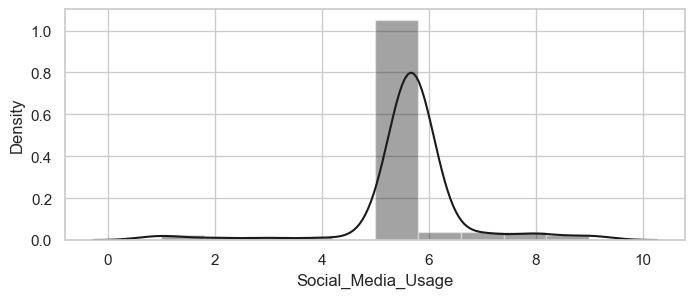

In [22]:
sns.distplot(profession.Social_Media_Usage,color='k',bins=10)

<Axes: xlabel='Career_Goals', ylabel='Density'>

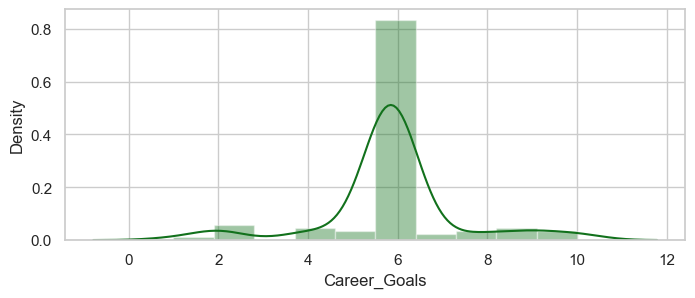

In [23]:
sns.distplot(profession.Career_Goals,color='g',bins=10)

<Axes: xlabel='University_Choices', ylabel='Density'>

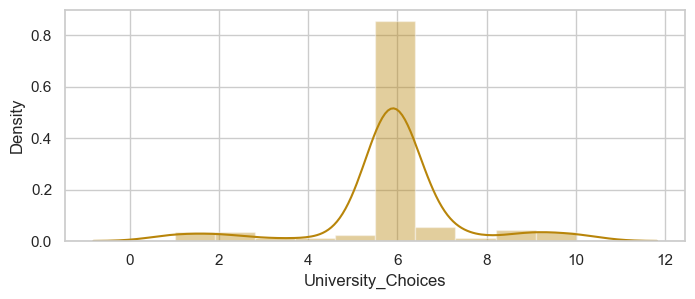

In [24]:
sns.distplot(profession.University_Choices,color='y',bins=10)

In [25]:
profession.head()

,gender,age,age_group,attention_span,creativity_score,logical_reasoning,verbal_intelligence,visual_intelligence,social_skills,motor_skills,...,Math_Interest,Computer_Games,Social_Media_Usage,Technology_Interest,Career_Goals,University_Choices,Future_Planning,primary_interest,secondary_interest,predicted_job
0,Male,11,9-12,4,4,6,4,7,3,5,...,7.000000,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111,Science,Drawing,Graphic Designer
1,Female,8,5-8,7,1,7,10,10,5,2,...,5.607143,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111,Animals,Drawing,Animal Caretaker
2,Male,17,16-18,3,2,10,10,5,9,3,...,5.607143,5.611111,5.666667,4.555556,9.000000,9.000000,1.000000,Artificial Intelligence,Psychology,AI Engineer
3,Female,15,13-15,6,1,7,3,3,2,9,...,5.607143,2.000000,7.000000,3.000000,5.851852,5.888889,6.111111,Coding,Sports,Software Developer
4,Female,12,9-12,2,5,10,10,7,10,7,...,6.000000,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111,Nature,Dance,Choreographer


<Axes: xlabel='gender', ylabel='count'>

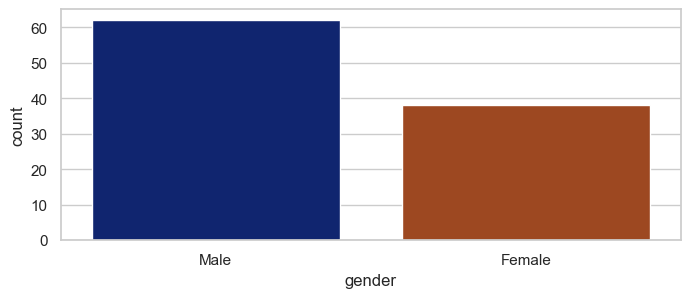

In [26]:
sns.countplot(data=profession,x='gender',palette='dark')

<Axes: xlabel='primary_interest', ylabel='count'>

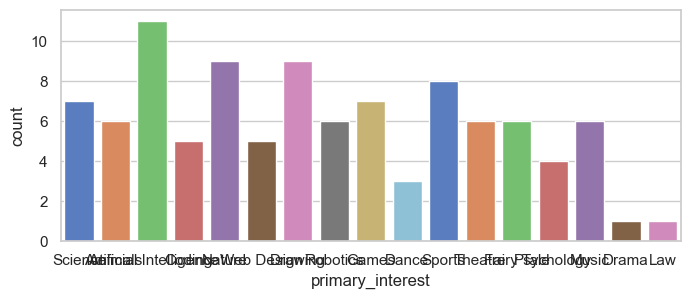

In [27]:
sns.countplot(data=profession,x='primary_interest',palette='muted')

<Axes: xlabel='secondary_interest', ylabel='count'>

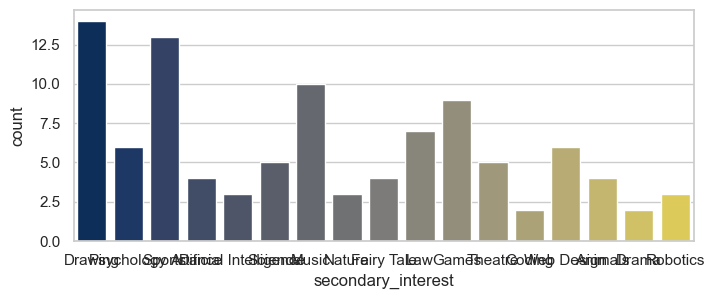

In [28]:
sns.countplot(data=profession,x='secondary_interest',palette='cividis')

In [29]:
profession.head()

,gender,age,age_group,attention_span,creativity_score,logical_reasoning,verbal_intelligence,visual_intelligence,social_skills,motor_skills,...,Math_Interest,Computer_Games,Social_Media_Usage,Technology_Interest,Career_Goals,University_Choices,Future_Planning,primary_interest,secondary_interest,predicted_job
0,Male,11,9-12,4,4,6,4,7,3,5,...,7.000000,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111,Science,Drawing,Graphic Designer
1,Female,8,5-8,7,1,7,10,10,5,2,...,5.607143,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111,Animals,Drawing,Animal Caretaker
2,Male,17,16-18,3,2,10,10,5,9,3,...,5.607143,5.611111,5.666667,4.555556,9.000000,9.000000,1.000000,Artificial Intelligence,Psychology,AI Engineer
3,Female,15,13-15,6,1,7,3,3,2,9,...,5.607143,2.000000,7.000000,3.000000,5.851852,5.888889,6.111111,Coding,Sports,Software Developer
4,Female,12,9-12,2,5,10,10,7,10,7,...,6.000000,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111,Nature,Dance,Choreographer


<Axes: xlabel='primary_interest', ylabel='count'>

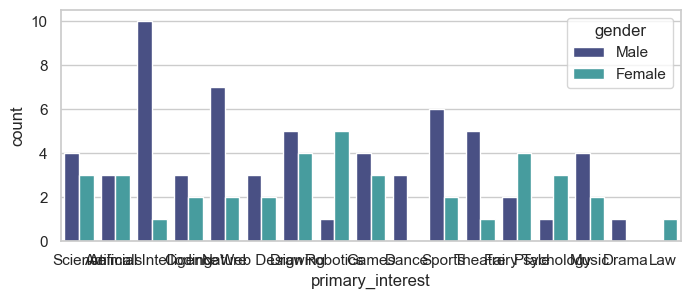

In [30]:
sns.countplot(data=profession,x='primary_interest',hue='gender',palette='mako')

<Axes: xlabel='secondary_interest', ylabel='count'>

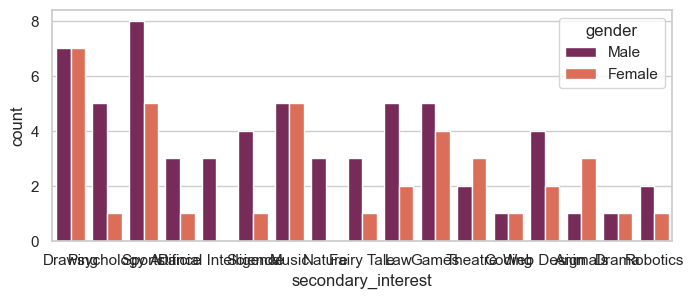

In [31]:
sns.countplot(data=profession,x='secondary_interest',hue='gender',palette='rocket')

In [32]:
profession.head()

,gender,age,age_group,attention_span,creativity_score,logical_reasoning,verbal_intelligence,visual_intelligence,social_skills,motor_skills,...,Math_Interest,Computer_Games,Social_Media_Usage,Technology_Interest,Career_Goals,University_Choices,Future_Planning,primary_interest,secondary_interest,predicted_job
0,Male,11,9-12,4,4,6,4,7,3,5,...,7.000000,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111,Science,Drawing,Graphic Designer
1,Female,8,5-8,7,1,7,10,10,5,2,...,5.607143,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111,Animals,Drawing,Animal Caretaker
2,Male,17,16-18,3,2,10,10,5,9,3,...,5.607143,5.611111,5.666667,4.555556,9.000000,9.000000,1.000000,Artificial Intelligence,Psychology,AI Engineer
3,Female,15,13-15,6,1,7,3,3,2,9,...,5.607143,2.000000,7.000000,3.000000,5.851852,5.888889,6.111111,Coding,Sports,Software Developer
4,Female,12,9-12,2,5,10,10,7,10,7,...,6.000000,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111,Nature,Dance,Choreographer


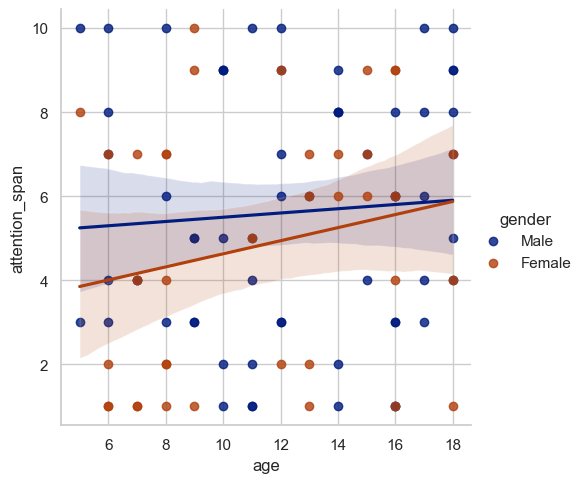

In [33]:
sns.lmplot(data=profession,x='age',y='attention_span',palette='dark',hue='gender')

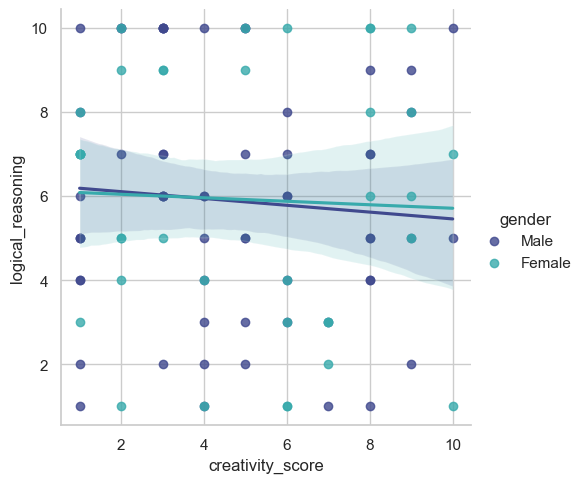

In [34]:
sns.lmplot(data=profession,x='creativity_score',y='logical_reasoning',palette='mako',hue='gender')

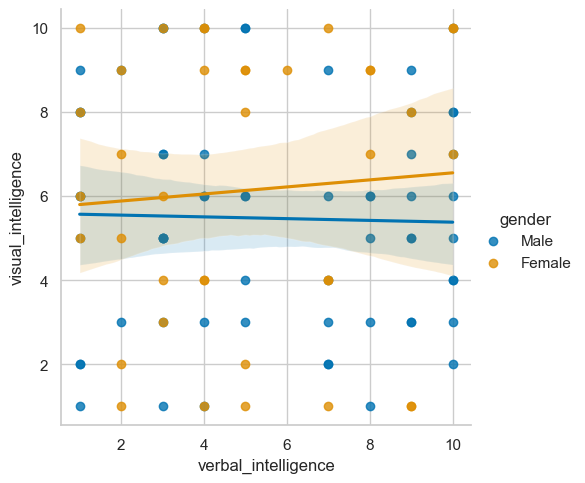

In [35]:
sns.lmplot(data=profession,x='verbal_intelligence',y='visual_intelligence',palette='colorblind',hue='gender')

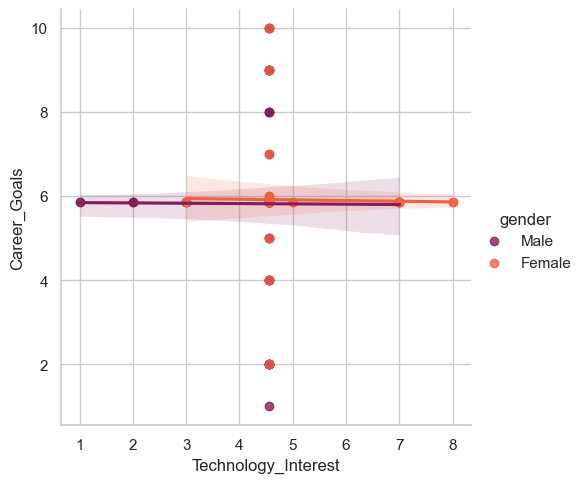

In [36]:
sns.lmplot(data=profession,x='Technology_Interest',y='Career_Goals',palette='rocket',hue='gender')

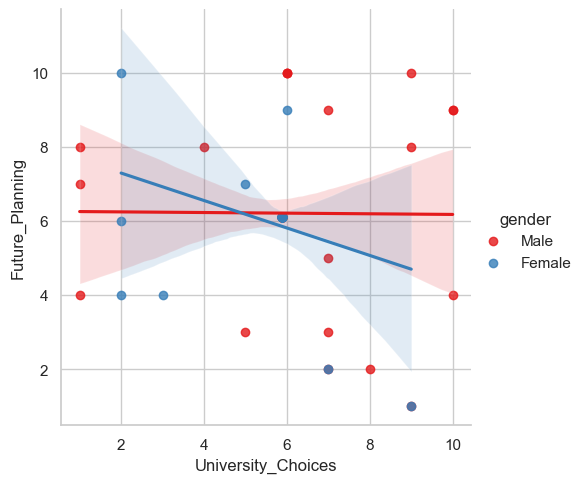

In [37]:
sns.lmplot(data=profession,x='University_Choices',y='Future_Planning',palette='Set1',hue='gender')

In [38]:
profession.head()

,gender,age,age_group,attention_span,creativity_score,logical_reasoning,verbal_intelligence,visual_intelligence,social_skills,motor_skills,...,Math_Interest,Computer_Games,Social_Media_Usage,Technology_Interest,Career_Goals,University_Choices,Future_Planning,primary_interest,secondary_interest,predicted_job
0,Male,11,9-12,4,4,6,4,7,3,5,...,7.000000,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111,Science,Drawing,Graphic Designer
1,Female,8,5-8,7,1,7,10,10,5,2,...,5.607143,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111,Animals,Drawing,Animal Caretaker
2,Male,17,16-18,3,2,10,10,5,9,3,...,5.607143,5.611111,5.666667,4.555556,9.000000,9.000000,1.000000,Artificial Intelligence,Psychology,AI Engineer
3,Female,15,13-15,6,1,7,3,3,2,9,...,5.607143,2.000000,7.000000,3.000000,5.851852,5.888889,6.111111,Coding,Sports,Software Developer
4,Female,12,9-12,2,5,10,10,7,10,7,...,6.000000,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111,Nature,Dance,Choreographer


<Axes: xlabel='gender', ylabel='age'>

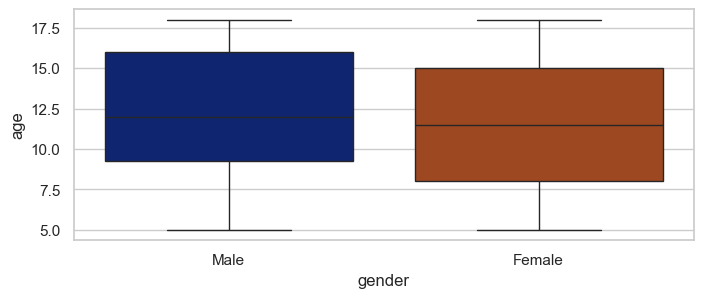

In [39]:
sns.boxplot(data=profession,x='gender',y='age',palette='dark')

<Axes: xlabel='primary_interest', ylabel='age'>

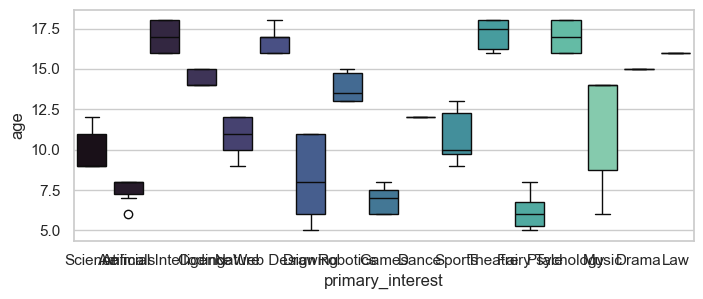

In [40]:
sns.boxplot(data=profession,x='primary_interest',y='age',palette='mako')

<Axes: xlabel='secondary_interest', ylabel='age'>

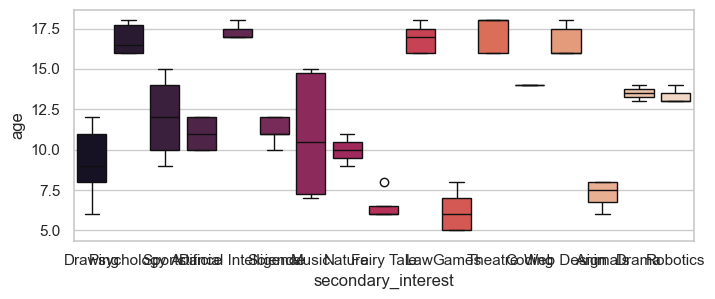

In [41]:
sns.boxplot(data=profession,x='secondary_interest',y='age',palette='rocket')

<Axes: xlabel='gender', ylabel='Future_Planning'>

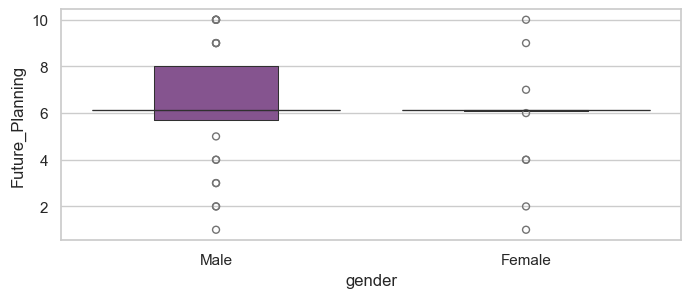

In [42]:
sns.boxenplot(data=profession,x='gender',y='Future_Planning',palette='magma')

<Axes: xlabel='gender', ylabel='Career_Goals'>

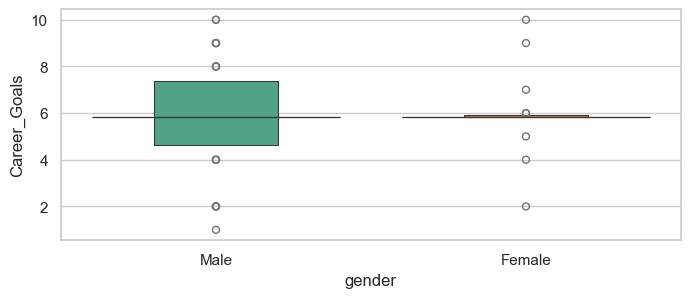

In [43]:
sns.boxenplot(data=profession,x='gender',y='Career_Goals',palette='Dark2')

In [44]:
profession.head()

,gender,age,age_group,attention_span,creativity_score,logical_reasoning,verbal_intelligence,visual_intelligence,social_skills,motor_skills,...,Math_Interest,Computer_Games,Social_Media_Usage,Technology_Interest,Career_Goals,University_Choices,Future_Planning,primary_interest,secondary_interest,predicted_job
0,Male,11,9-12,4,4,6,4,7,3,5,...,7.000000,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111,Science,Drawing,Graphic Designer
1,Female,8,5-8,7,1,7,10,10,5,2,...,5.607143,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111,Animals,Drawing,Animal Caretaker
2,Male,17,16-18,3,2,10,10,5,9,3,...,5.607143,5.611111,5.666667,4.555556,9.000000,9.000000,1.000000,Artificial Intelligence,Psychology,AI Engineer
3,Female,15,13-15,6,1,7,3,3,2,9,...,5.607143,2.000000,7.000000,3.000000,5.851852,5.888889,6.111111,Coding,Sports,Software Developer
4,Female,12,9-12,2,5,10,10,7,10,7,...,6.000000,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111,Nature,Dance,Choreographer


<Axes: xlabel='gender', ylabel='age'>

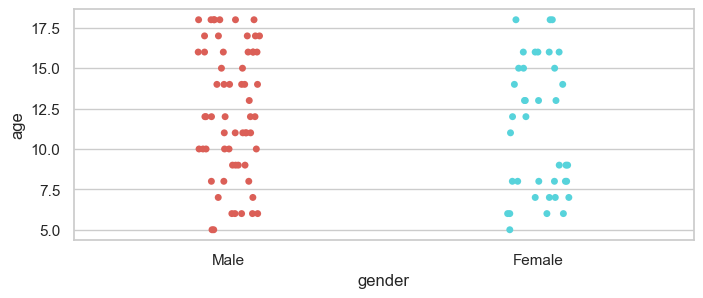

In [45]:
sns.stripplot(data=profession,x='gender',y='age',palette='hls')

<Axes: xlabel='gender', ylabel='University_Choices'>

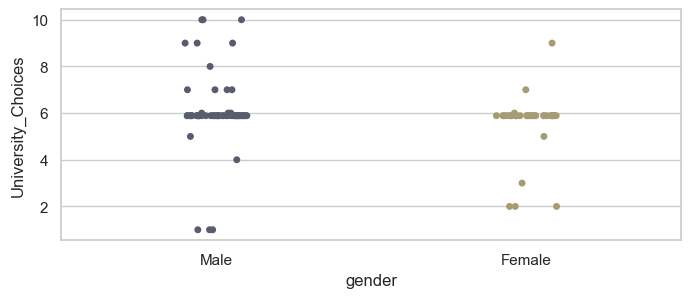

In [46]:
sns.stripplot(data=profession,x='gender',y='University_Choices',palette='cividis')

<Axes: xlabel='gender', ylabel='attention_span'>

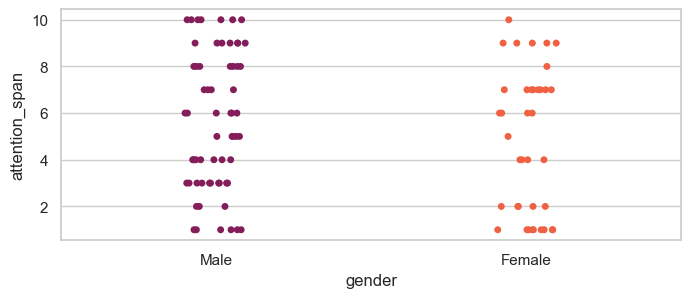

In [47]:
sns.stripplot(data=profession,x='gender',y='attention_span',palette='rocket')

<Axes: xlabel='gender', ylabel='Future_Planning'>

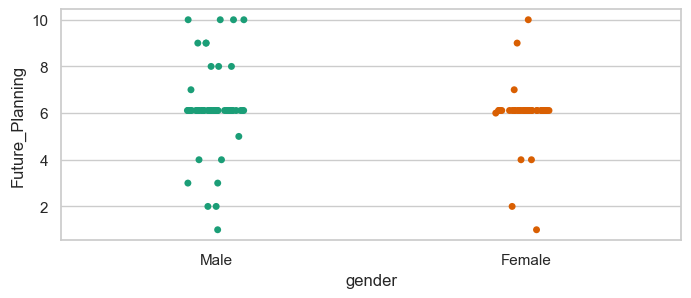

In [48]:
sns.stripplot(data=profession,x='gender',y='Future_Planning',palette='Dark2')

In [49]:
profession.head()

,gender,age,age_group,attention_span,creativity_score,logical_reasoning,verbal_intelligence,visual_intelligence,social_skills,motor_skills,...,Math_Interest,Computer_Games,Social_Media_Usage,Technology_Interest,Career_Goals,University_Choices,Future_Planning,primary_interest,secondary_interest,predicted_job
0,Male,11,9-12,4,4,6,4,7,3,5,...,7.000000,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111,Science,Drawing,Graphic Designer
1,Female,8,5-8,7,1,7,10,10,5,2,...,5.607143,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111,Animals,Drawing,Animal Caretaker
2,Male,17,16-18,3,2,10,10,5,9,3,...,5.607143,5.611111,5.666667,4.555556,9.000000,9.000000,1.000000,Artificial Intelligence,Psychology,AI Engineer
3,Female,15,13-15,6,1,7,3,3,2,9,...,5.607143,2.000000,7.000000,3.000000,5.851852,5.888889,6.111111,Coding,Sports,Software Developer
4,Female,12,9-12,2,5,10,10,7,10,7,...,6.000000,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111,Nature,Dance,Choreographer


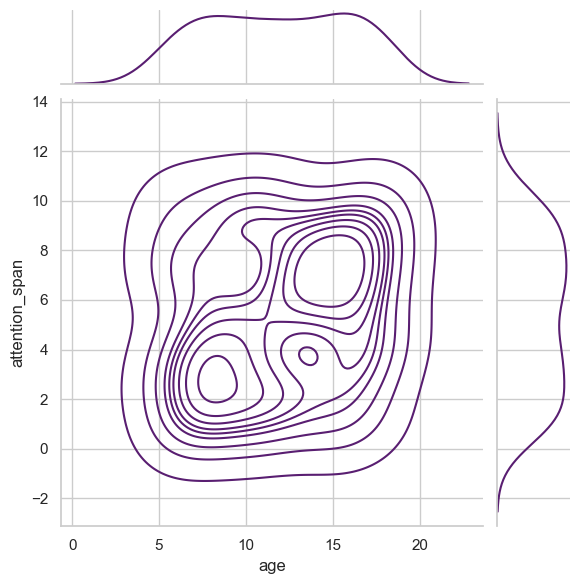

In [50]:
sns.jointplot(data=profession,x='age',y='attention_span',color='m',kind='kde')

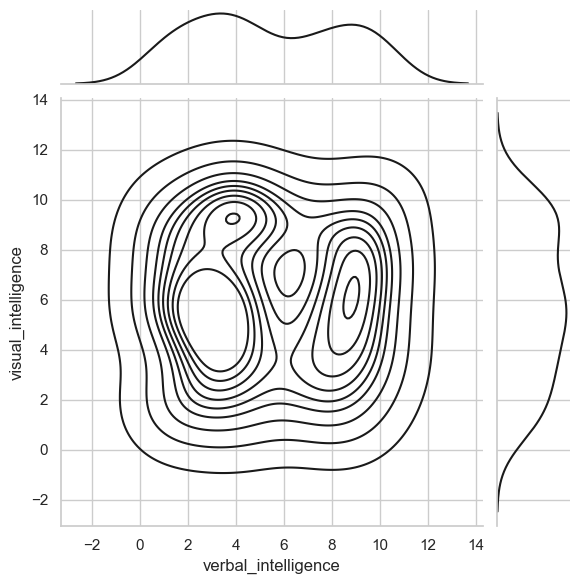

In [51]:
sns.jointplot(data=profession,x='verbal_intelligence',y='visual_intelligence',color='k',kind='kde')

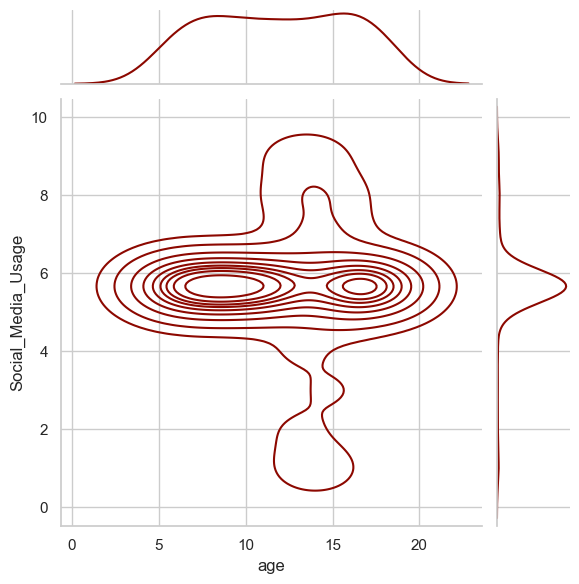

In [52]:
sns.jointplot(data=profession,x='age',y='Social_Media_Usage',color='r',kind='kde')

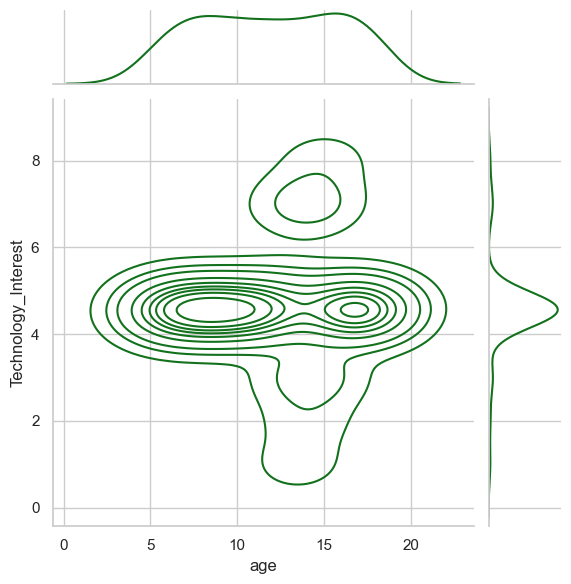

In [53]:
sns.jointplot(data=profession,x='age',y='Technology_Interest',color='g',kind='kde')

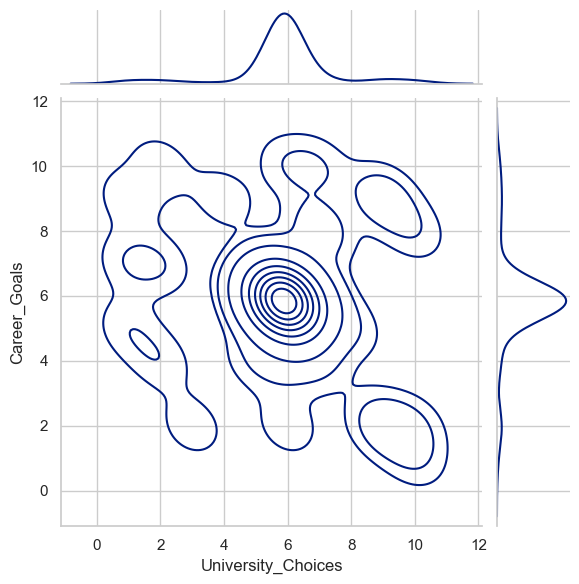

In [54]:
sns.jointplot(data=profession,x='University_Choices',y='Career_Goals',color='b',kind='kde')

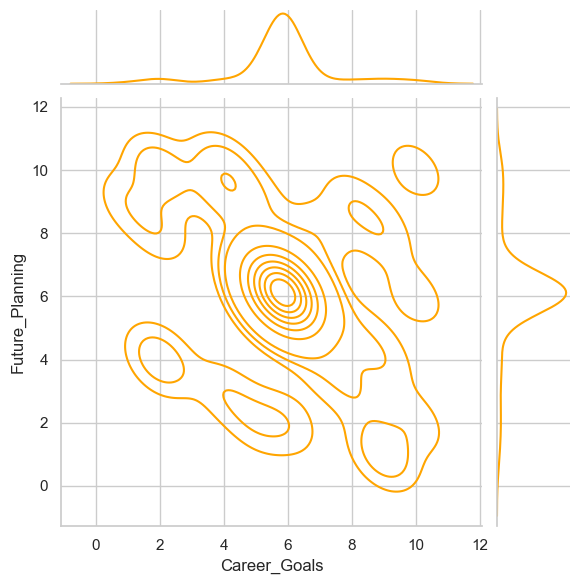

In [55]:
sns.jointplot(data=profession,x='Career_Goals',y='Future_Planning',color='orange',kind='kde')

In [56]:
profession.head()

,gender,age,age_group,attention_span,creativity_score,logical_reasoning,verbal_intelligence,visual_intelligence,social_skills,motor_skills,...,Math_Interest,Computer_Games,Social_Media_Usage,Technology_Interest,Career_Goals,University_Choices,Future_Planning,primary_interest,secondary_interest,predicted_job
0,Male,11,9-12,4,4,6,4,7,3,5,...,7.000000,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111,Science,Drawing,Graphic Designer
1,Female,8,5-8,7,1,7,10,10,5,2,...,5.607143,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111,Animals,Drawing,Animal Caretaker
2,Male,17,16-18,3,2,10,10,5,9,3,...,5.607143,5.611111,5.666667,4.555556,9.000000,9.000000,1.000000,Artificial Intelligence,Psychology,AI Engineer
3,Female,15,13-15,6,1,7,3,3,2,9,...,5.607143,2.000000,7.000000,3.000000,5.851852,5.888889,6.111111,Coding,Sports,Software Developer
4,Female,12,9-12,2,5,10,10,7,10,7,...,6.000000,5.611111,5.666667,4.555556,5.851852,5.888889,6.111111,Nature,Dance,Choreographer


<Axes: xlabel='age', ylabel='Density'>

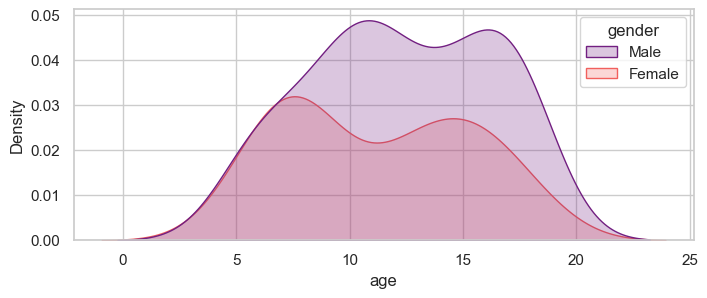

In [57]:
sns.kdeplot(data=profession,x='age',hue='gender',palette='magma',fill=True)

<Axes: xlabel='attention_span', ylabel='Density'>

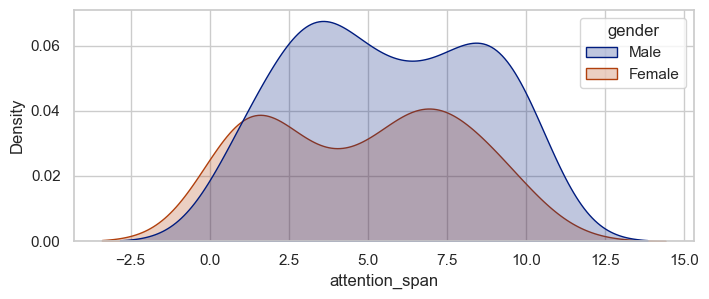

In [58]:
sns.kdeplot(data=profession,x='attention_span',hue='gender',palette='dark',fill=True)

<Axes: xlabel='University_Choices', ylabel='Density'>

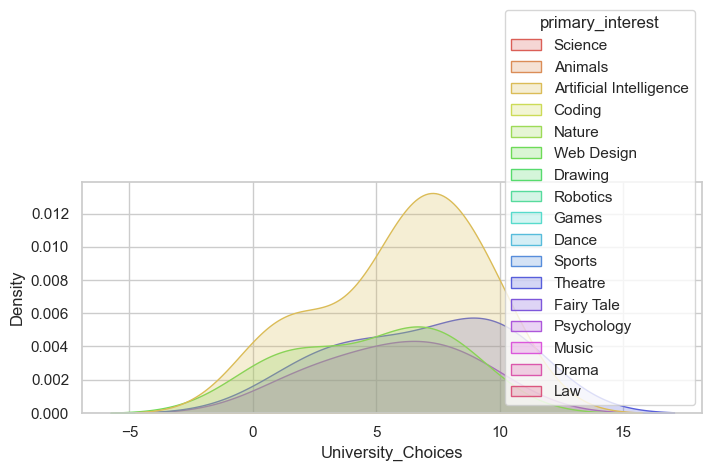

In [59]:
sns.kdeplot(data=profession,x='University_Choices',hue='primary_interest',palette='hls',fill=True)

<Axes: xlabel='age', ylabel='Density'>

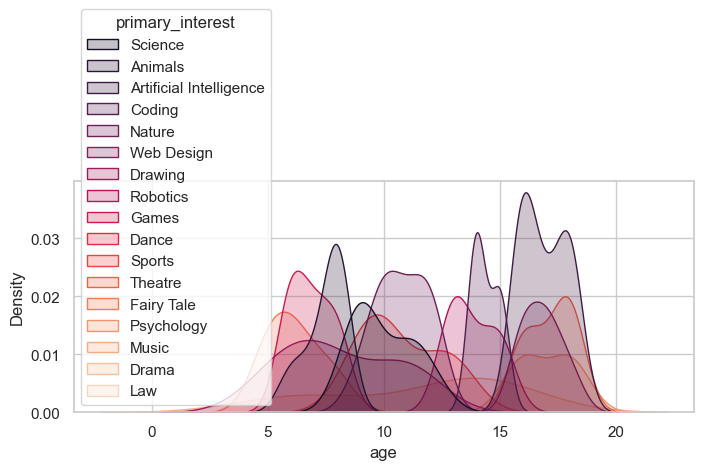

In [60]:
sns.kdeplot(data=profession,x='age',hue='primary_interest',palette='rocket',fill=True)

<Axes: xlabel='Future_Planning', ylabel='Density'>

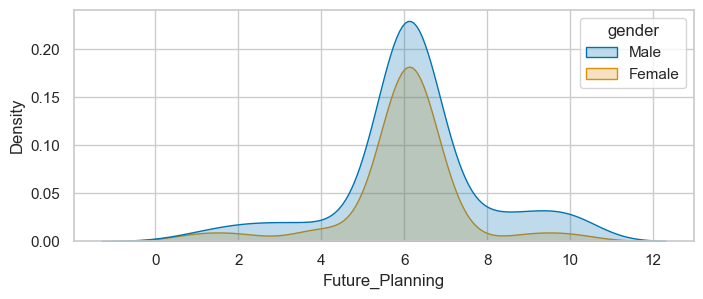

In [61]:
sns.kdeplot(data=profession,x='Future_Planning',hue='gender',palette='colorblind',fill=True)

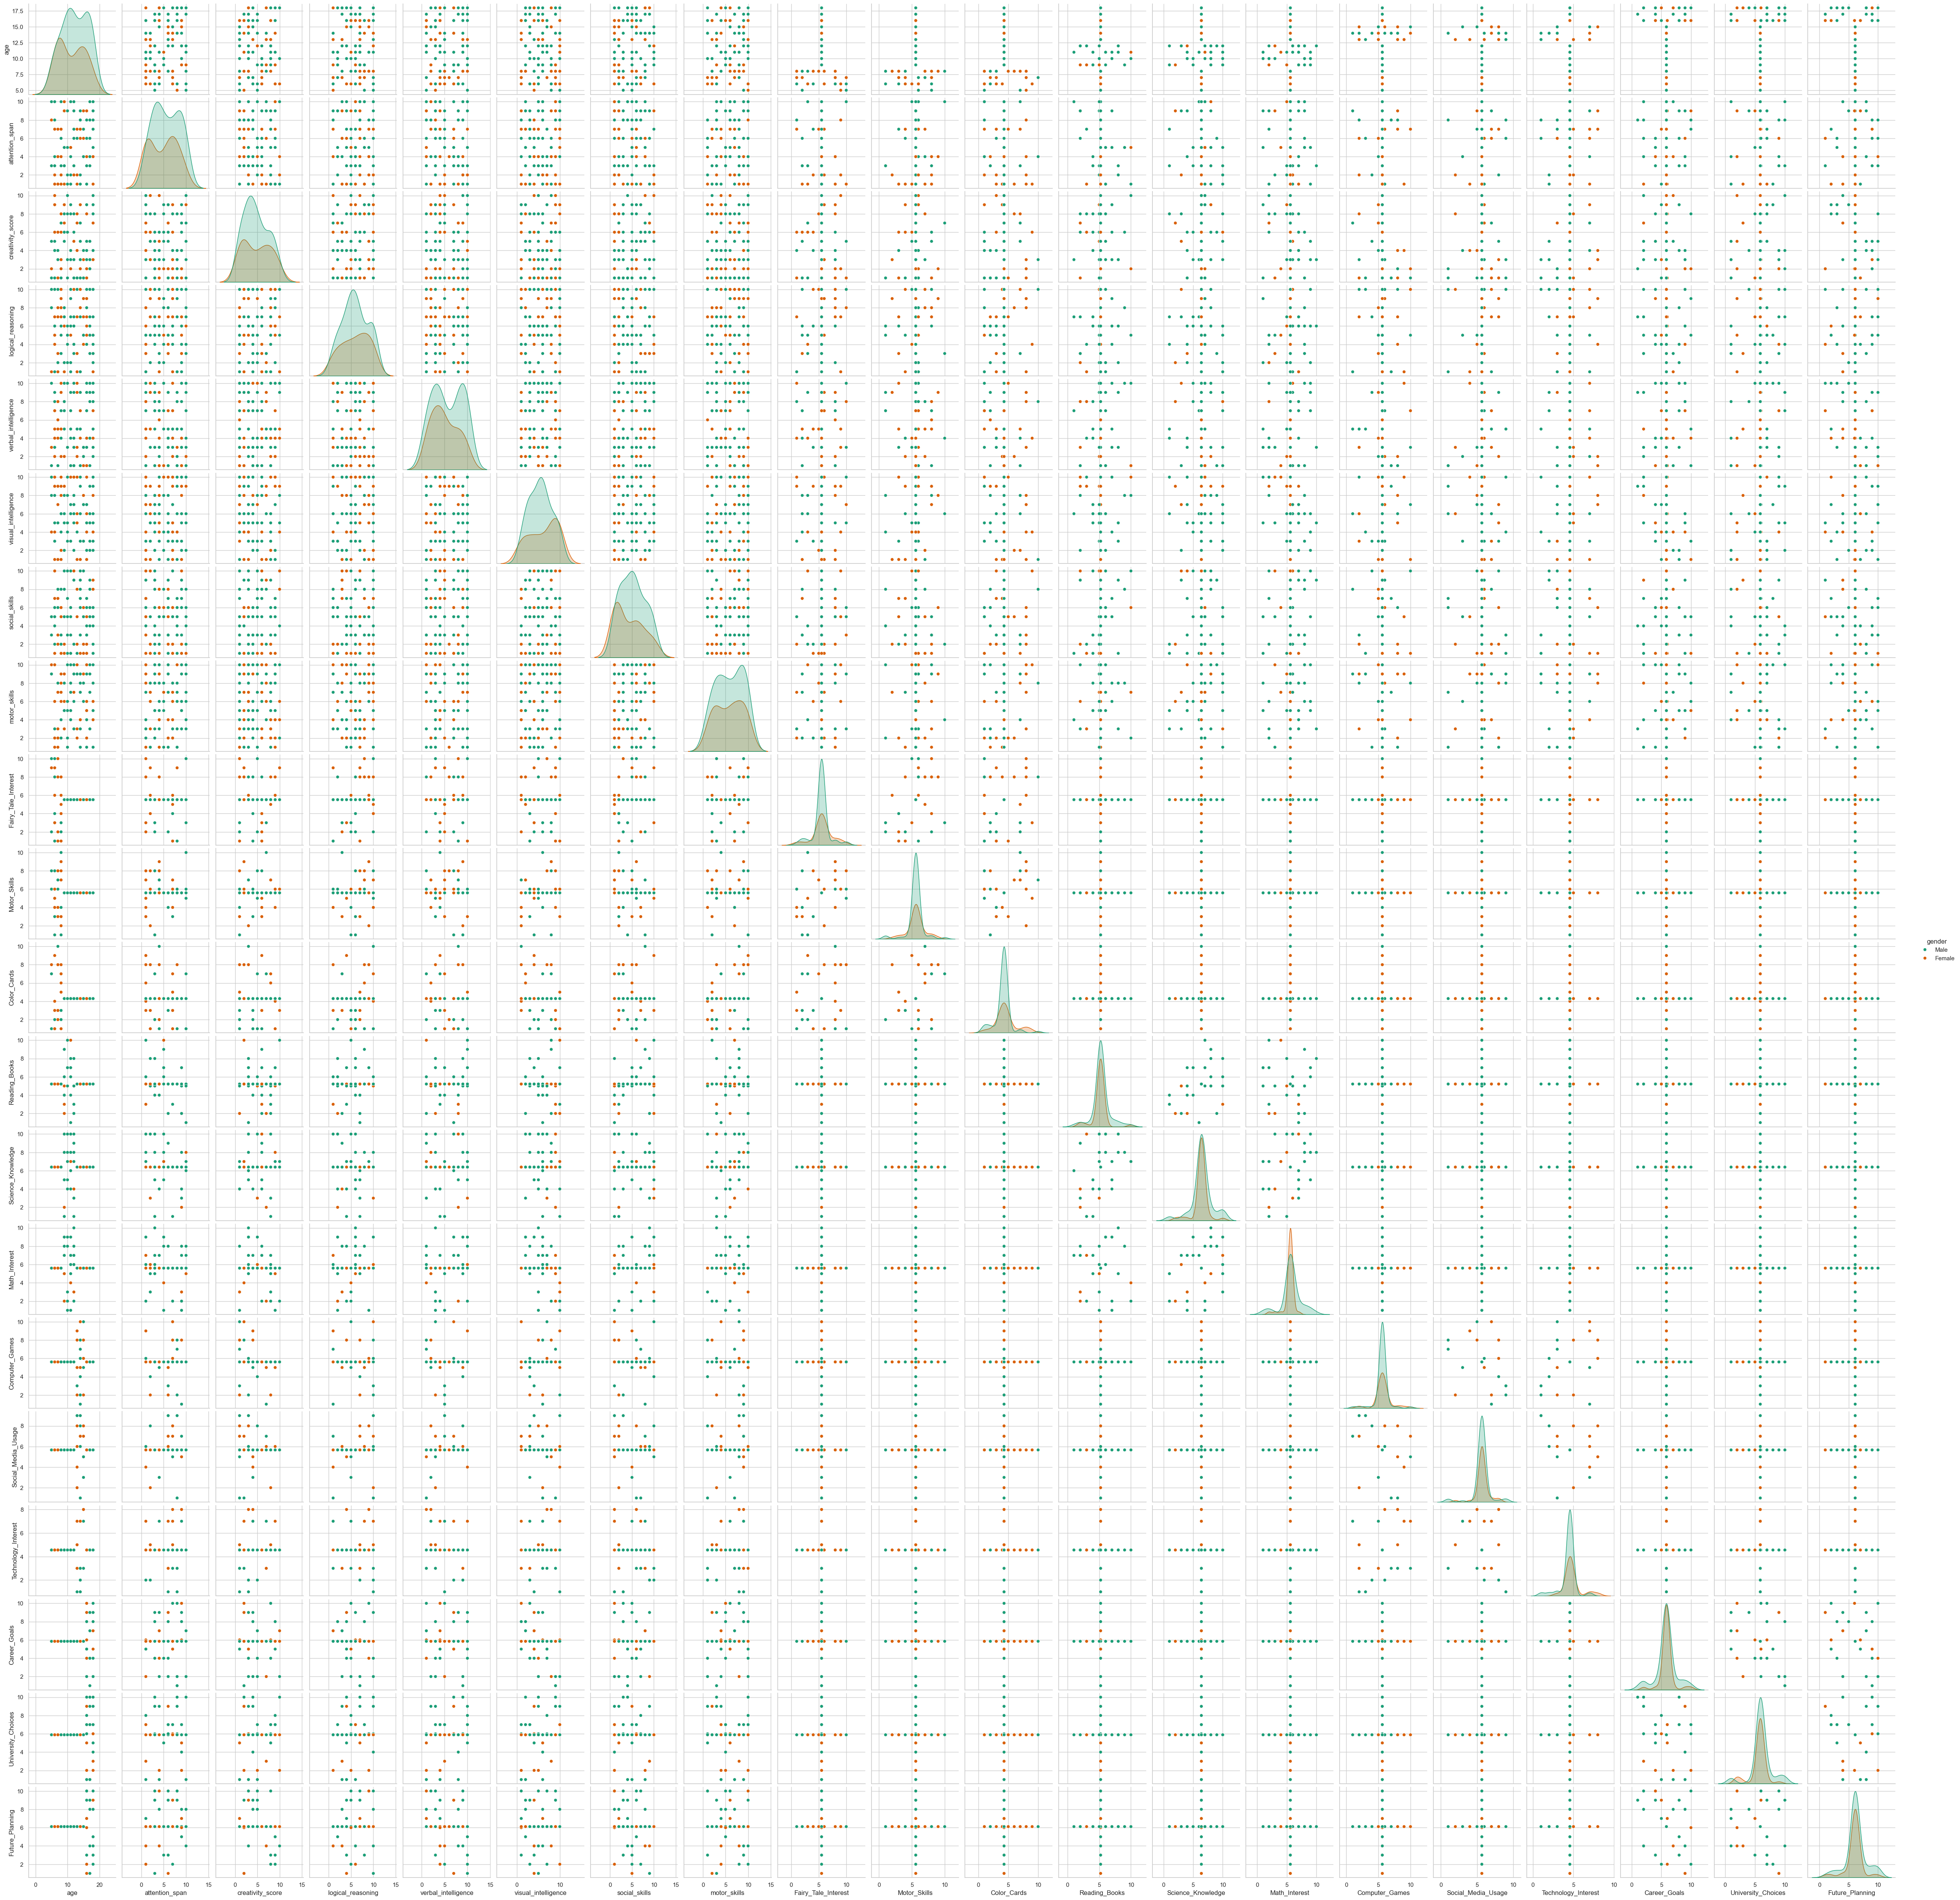

In [62]:
sns.pairplot(profession, hue="gender",palette='Dark2')